# EfficientNet - CT Scan Lung Disease Classification

**Classes:** ACA | LCC | NORM | SCC

Dataset path: `dataset/ct-scan/{aca, lcc, norm, scc}`


## 1. Install & Import Dependencies


In [ ]:
# Uncomment if packages not installed
!pip install torch torchvision timm scikit-learn matplotlib seaborn tqdm train -q

import os
from typing import Literal
from os.path import join
import copy
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import timm

from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

print(f'PyTorch version : {torch.__version__}')
print(f'timm version    : {timm.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device    : {DEVICE}')

PyTorch version : 2.10.0+cu128
timm version    : 1.0.25
CUDA available  : True
Using device    : cuda


## 2. Configuration


In [ ]:
# ── Paths ────────────────────────────────────────────────────────────────────
path = ".."
output = ".."
kaggle = False

if kaggle:
    path = "/kaggle/input/datasets/ebadansari/dataset"
    output = join("kaggle", "working")

dataset: Literal["ct-scan", "pathalogy"] = "pathalogy"
DATA_DIR   = Path(join(path, 'dataset', dataset))   # adjust if needed
SAVE_DIR   = Path(join(output, 'outputs/resnet'))
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# ── Model choice (change variant here) ───────────────────────────────────────
# Options: 'efficientnet_b0' ... 'efficientnet_b7'
#          'efficientnetv2_s', 'efficientnetv2_m', 'efficientnetv2_l'
MODEL_NAME  = 'efficientnet_b3'

# ── Hyperparameters ───────────────────────────────────────────────────────────
IMG_SIZE    = 300    # B3 native resolution; use 224 for B0, 380 for B5
BATCH_SIZE  = 32
NUM_EPOCHS  = 30
LR          = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE    = 7

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

CLASS_NAMES = ['aca', 'lcc', 'norm', 'scc']
NUM_CLASSES = len(CLASS_NAMES)
print('Model    :', MODEL_NAME)
print('Classes  :', CLASS_NAMES)

Model    : efficientnet_b3
Classes  : ['aca', 'lcc', 'norm', 'scc']


## 3. Data Transforms & Dataset


In [11]:
# Use timm's recommended stats for EfficientNet pretrained on ImageNet
BATCH_SIZE = 16
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

full_dataset = datasets.ImageFolder(DATA_DIR)
print(f'Total images : {len(full_dataset)}')
print(f'Class map    : {full_dataset.class_to_idx}')

n_total = len(full_dataset)
n_train = int(n_total * TRAIN_RATIO)
n_val   = int(n_total * VAL_RATIO)
n_test  = n_total - n_train - n_val

train_ds, val_ds, test_ds = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

class SubsetWithTransform(torch.utils.data.Subset):
    def __init__(self, dataset, indices, transform):
        super().__init__(dataset, indices)
        self._transform = transform
        
    def __getitem__(self, idx):
        # Access original image path from the ImageFolder dataset
        img_path, label = self.dataset.imgs[self.indices[idx]]
        from PIL import Image
        img = Image.open(img_path).convert('RGB')
        if self._transform:
            img = self._transform(img)
        return img, label

    # Required for PyTorch Subset subclasses to work with DataLoader in newer versions
    def __getitems__(self, indices):
        return [self.__getitem__(idx) for idx in indices]

# Set num_workers=0 to avoid multiprocessing issues on Windows
train_loader = DataLoader(
    SubsetWithTransform(full_dataset, train_ds.indices, train_tf),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True
)
val_loader = DataLoader(
    SubsetWithTransform(full_dataset, val_ds.indices, eval_tf),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True
)
test_loader = DataLoader(
    SubsetWithTransform(full_dataset, test_ds.indices, eval_tf),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True
)

print(f'Train: {n_train} | Val: {n_val} | Test: {n_test}')

Total images : 864
Class map    : {'aca': 0, 'lcc': 1, 'norm': 2, 'scc': 3}
Train: 604 | Val: 129 | Test: 131


## 4. Visualise Sample Images


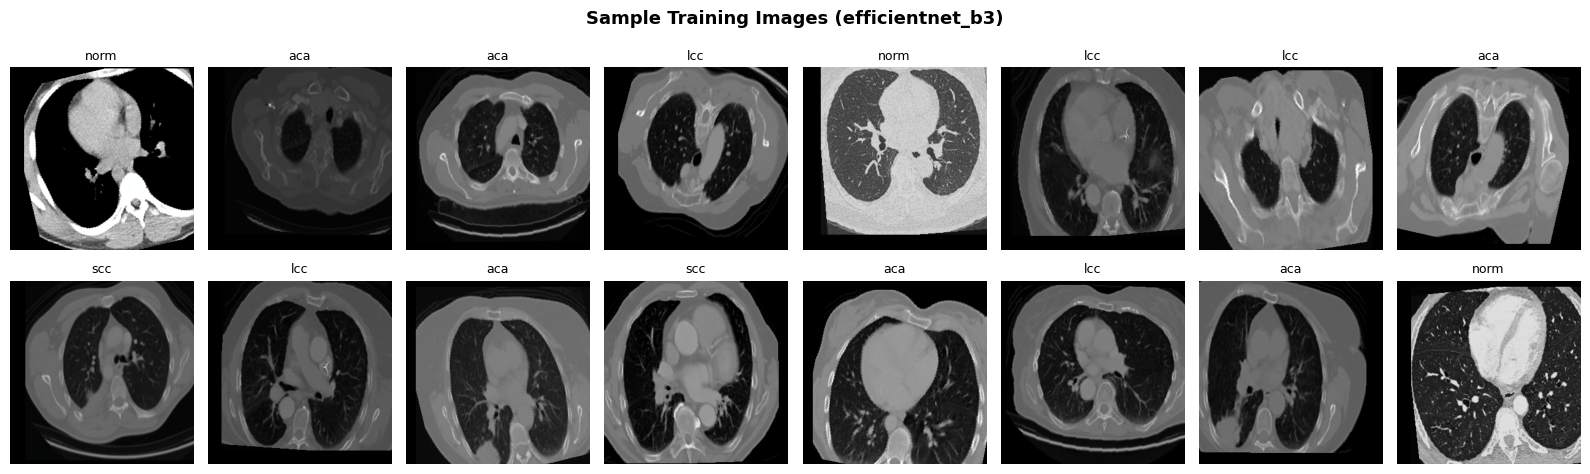

In [12]:
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    inp = np.clip(np.array(STD) * inp + np.array(MEAN), 0, 1)
    plt.imshow(inp)
    if title: plt.title(title, fontsize=9)
    plt.axis('off')

imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i, ax in enumerate(axes.flatten()):
    plt.sca(ax)
    imshow(imgs[i], CLASS_NAMES[labels[i]])
plt.suptitle(f'Sample Training Images ({MODEL_NAME})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'sample_images.png', dpi=150)
plt.show()

## 5. Build EfficientNet Model (timm + Transfer Learning)


In [13]:
def build_efficientnet(model_name, num_classes, dropout=0.4):
    """Load pretrained EfficientNet via timm and replace the classifier head."""
    model = timm.create_model(
        model_name,
        pretrained=True,
        num_classes=0,      # remove default head
        drop_rate=dropout
    )
    in_features = model.num_features
    # Custom head
    model.classifier = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, 256),
        nn.SiLU(),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes)
    )
    return model

model = build_efficientnet(MODEL_NAME, NUM_CLASSES).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model            : {MODEL_NAME}')
print(f'Total params     : {total_params:,}')
print(f'Trainable params : {trainable_params:,}')

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Model            : efficientnet_b3
Total params     : 11,090,732
Trainable params : 11,090,732


## 6. (Optional) Layer-wise Freezing Strategy


In [14]:
# Uncomment to freeze all backbone layers and only train head first
# for name, param in model.named_parameters():
#     if 'classifier' not in name:
#         param.requires_grad = False

# After ~5 epochs, unfreeze all layers:
# for param in model.parameters():
#     param.requires_grad = True

print('All layers trainable (fine-tuning mode).')

All layers trainable (fine-tuning mode).


## 7. Loss, Optimiser & Scheduler


In [15]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Separate LR for backbone vs head (discriminative learning rates)
head_params     = list(model.classifier.parameters())
backbone_params = [p for n, p in model.named_parameters() if 'classifier' not in n]

optimizer = optim.AdamW([
    {'params': backbone_params, 'lr': LR * 0.1},
    {'params': head_params,     'lr': LR}
], weight_decay=WEIGHT_DECAY)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[LR * 0.1, LR],
    epochs=NUM_EPOCHS,
    steps_per_epoch=len(train_loader)
)

print('Criterion  :', criterion)
print('Optimizer  :', optimizer.__class__.__name__)
print('Scheduler  :', scheduler.__class__.__name__)

Criterion  : CrossEntropyLoss()
Optimizer  : AdamW
Scheduler  : OneCycleLR


## 8. Training Loop (with Mixed Precision)


In [16]:
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

def train_one_epoch(model, loader, optimizer, criterion, scheduler, scaler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(loader, desc='  Train', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        total_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        total_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total


history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0
best_weights = None
patience_cnt = 0

print(f'Training {MODEL_NAME} for {NUM_EPOCHS} epochs ...\n')
start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    t_loss, t_acc = train_one_epoch(model, train_loader, optimizer, criterion, scheduler, scaler)
    v_loss, v_acc = evaluate(model, val_loader, criterion)

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    flag = ''
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        best_weights = copy.deepcopy(model.state_dict())
        torch.save(best_weights, SAVE_DIR / f'{MODEL_NAME}_best.pth')
        patience_cnt = 0
        flag = '  ✓ saved'
    else:
        patience_cnt += 1

    lr_now = optimizer.param_groups[-1]['lr']
    print(f'Epoch [{epoch:02d}/{NUM_EPOCHS}]  '
          f'Train Loss: {t_loss:.4f}  Acc: {t_acc*100:.2f}%  |  '
          f'Val Loss: {v_loss:.4f}  Acc: {v_acc*100:.2f}%  '
          f'LR: {lr_now:.2e}{flag}')

    if patience_cnt >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}.')
        break

elapsed = time.time() - start_time
print(f'\nTraining complete in {elapsed/60:.1f} min  |  Best Val Acc: {best_val_acc*100:.2f}%')
model.load_state_dict(best_weights)

/tmp/ipykernel_261/933809096.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


Training efficientnet_b3 for 30 epochs ...



  Train:   0%|          | 0/38 [00:00<?, ?it/s]/tmp/ipykernel_261/933809096.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_261/933809096.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Epoch [01/30]  Train Loss: 1.3829  Acc: 26.49%  |  Val Loss: 1.3821  Acc: 27.13%  LR: 6.91e-06  ✓ saved


Epoch [02/30]  Train Loss: 1.3674  Acc: 32.28%  |  Val Loss: nan  Acc: 31.78%  LR: 1.53e-05  ✓ saved


...

Epoch [27/30]  Train Loss: 0.8465  Acc: 73.34%  |  Val Loss: 5.2480  Acc: 68.22%  LR: 4.87e-06


Epoch [28/30]  Train Loss: 0.8431  Acc: 73.51%  |  Val Loss: 0.8904  Acc: 70.54%  LR: 2.16e-06


Epoch [29/30]  Train Loss: 0.8611  Acc: 72.52%  |  Val Loss: 5.4997  Acc: 67.44%  LR: 5.30e-07


Epoch [30/30]  Train Loss: 0.8559  Acc: 73.18%  |  Val Loss: 1.5026  Acc: 70.54%  LR: 7.87e-10

Training complete in 7.5 min  |  Best Val Acc: 71.32%


<All keys matched successfully>

## 9. Training Curves


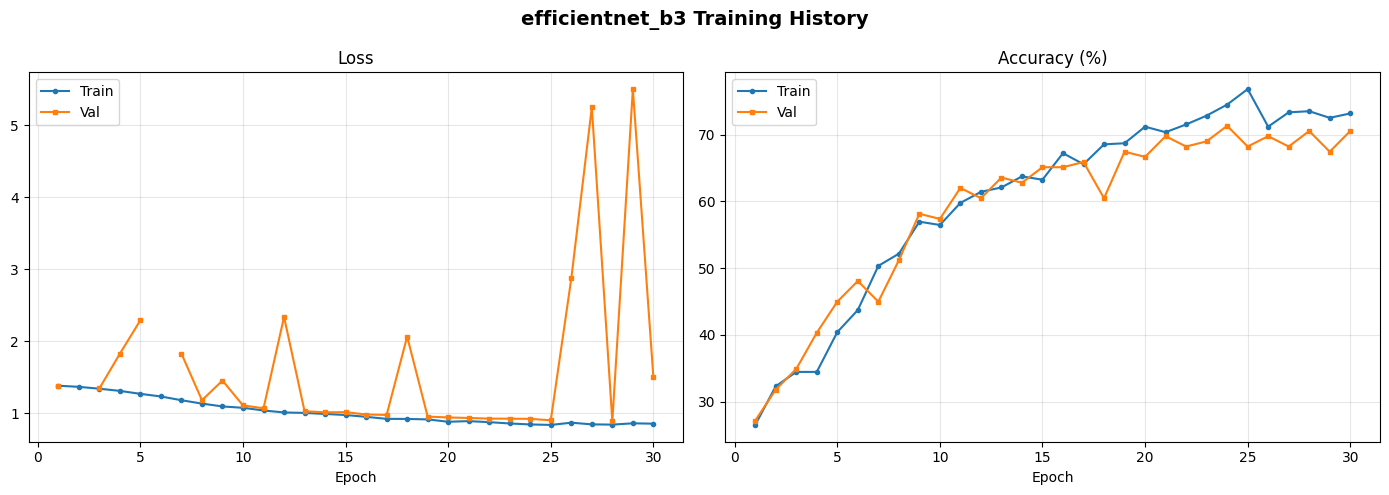

In [17]:
epochs_ran = range(1, len(history['train_loss']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_ran, history['train_loss'], label='Train', marker='o', markersize=3)
ax1.plot(epochs_ran, history['val_loss'],   label='Val',   marker='s', markersize=3)
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_ran, [a*100 for a in history['train_acc']], label='Train', marker='o', markersize=3)
ax2.plot(epochs_ran, [a*100 for a in history['val_acc']],   label='Val',   marker='s', markersize=3)
ax2.set_title('Accuracy (%)'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle(f'{MODEL_NAME} Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'training_curves.png', dpi=150)
plt.show()

## 10. Evaluate on Test Set


In [18]:
@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

y_true, y_pred, y_probs = get_predictions(model, test_loader)
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f'Test Loss : {test_loss:.4f}')
print(f'Test Acc  : {test_acc*100:.2f}%')

/tmp/ipykernel_261/2122093821.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_261/933809096.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Test Loss : 0.8876
Test Acc  : 75.57%


## 11. Classification Report & Confusion Matrix



Classification Report:
              precision    recall  f1-score   support

         aca       0.84      0.65      0.73        48
         lcc       0.92      0.48      0.63        23
        norm       0.93      0.96      0.95        28
         scc       0.57      0.94      0.71        32

    accuracy                           0.76       131
   macro avg       0.81      0.76      0.75       131
weighted avg       0.81      0.76      0.75       131



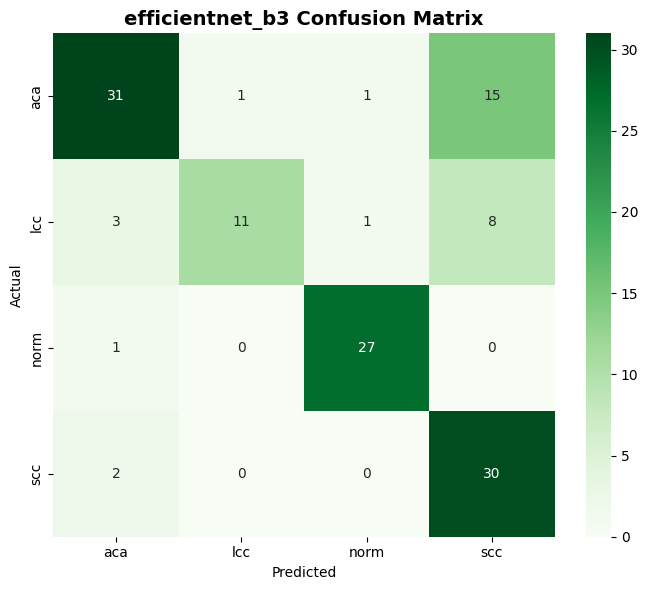

In [19]:
print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'{MODEL_NAME} Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

## 12. Save Final Model


In [20]:
torch.save({
    'model_name'       : MODEL_NAME,
    'model_state_dict' : model.state_dict(),
    'class_names'      : CLASS_NAMES,
    'test_accuracy'    : test_acc,
    'history'          : history,
}, SAVE_DIR / f'{MODEL_NAME}_final.pth')

print(f'Model saved to {SAVE_DIR / f"{MODEL_NAME}_final.pth"}')
print(f'Best Val Acc : {best_val_acc*100:.2f}%')
print(f'Test Acc     : {test_acc*100:.2f}%')

Model saved to /kaggle/working/outputs/resnet/efficientnet_b3_final.pth
Best Val Acc : 71.32%
Test Acc     : 75.57%
